# 4.1 Linear Regression Model

This notebook trains a Linear Regression model to predict charging station suitability scores for cities.

## Objectives:
1. Load processed data
2. Train Linear Regression model
3. Evaluate model performance
4. Analyze feature importance
5. Save trained model


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# Load processed data
X_train = np.load('../../data/processed/X_train.npy')
X_test = np.load('../../data/processed/X_test.npy')
y_train = np.load('../../data/processed/y_train.npy')
y_test = np.load('../../data/processed/y_test.npy')
feature_columns = joblib.load('../../data/processed/feature_columns.pkl')

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Features: {feature_columns}")
print(f"Target range: {y_train.min():.2f} - {y_train.max():.2f}")


Training set shape: (716, 11)
Test set shape: (179, 11)
Features: ['EV_Count', 'Avg_Range', 'Range_Std', 'Avg_MSRP', 'Avg_Age', 'BEV_Ratio', 'PHEV_Ratio', 'Make_Diversity', 'Distance_From_Seattle', 'Distance_From_Spokane', 'County_Encoded']
Target range: nan - nan


In [5]:
# Train Linear Regression Model
print("Training Linear Regression Model...")

# Ensure targets are 1D numpy arrays
y_train = np.array(y_train).ravel()
y_test = np.array(y_test).ravel()

# Check for NaNs in targets and remove corresponding samples
train_nans = np.isnan(y_train).sum()
test_nans = np.isnan(y_test).sum()
print(f"y_train NaNs: {train_nans}, y_test NaNs: {test_nans}")

if train_nans > 0:
    print("Removing samples with NaN targets from training set...")
    mask = ~np.isnan(y_train)
    X_train = X_train[mask]
    y_train = y_train[mask]
    print(f"New training shape: {X_train.shape}, {y_train.shape}")

if test_nans > 0:
    print("Removing samples with NaN targets from test set...")
    mask = ~np.isnan(y_test)
    X_test = X_test[mask]
    y_test = y_test[mask]
    print(f"New test shape: {X_test.shape}, {y_test.shape}")

# Optionally save cleaned arrays for reproducibility (does not overwrite originals)
np.save('../../data/processed/X_train_clean.npy', X_train)
np.save('../../data/processed/y_train_clean.npy', y_train)
np.save('../../data/processed/X_test_clean.npy', X_test)
np.save('../../data/processed/y_test_clean.npy', y_test)
print("✓ Cleaned arrays saved to data/processed (clean copies)")

# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

print("✓ Model trained successfully")

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\nModel Performance:")
print("=" * 30)
print(f"Training MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Training Linear Regression Model...
y_train NaNs: 397, y_test NaNs: 92
Removing samples with NaN targets from training set...
New training shape: (319, 11), (319,)
Removing samples with NaN targets from test set...
New test shape: (87, 11), (87,)
✓ Cleaned arrays saved to data/processed (clean copies)
✓ Model trained successfully

Model Performance:
Training MSE: 0.0009
Test MSE: 0.0014
Training R²: 1.0000
Test R²: 1.0000
Training MAE: 0.0176
Test MAE: 0.0180


Analyzing Feature Importance...
Feature Importance (by coefficient magnitude):
                  Feature  Coefficient  Abs_Coefficient
0                EV_Count   690.454161       690.454161
4                 Avg_Age    -0.201895         0.201895
1               Avg_Range     0.104453         0.104453
2               Range_Std     0.095256         0.095256
3                Avg_MSRP    -0.040387         0.040387
9   Distance_From_Spokane    -0.021735         0.021735
8   Distance_From_Seattle     0.016511         0.016511
7          Make_Diversity    -0.009216         0.009216
10         County_Encoded     0.002909         0.002909
5               BEV_Ratio     0.000666         0.000666
6              PHEV_Ratio    -0.000666         0.000666


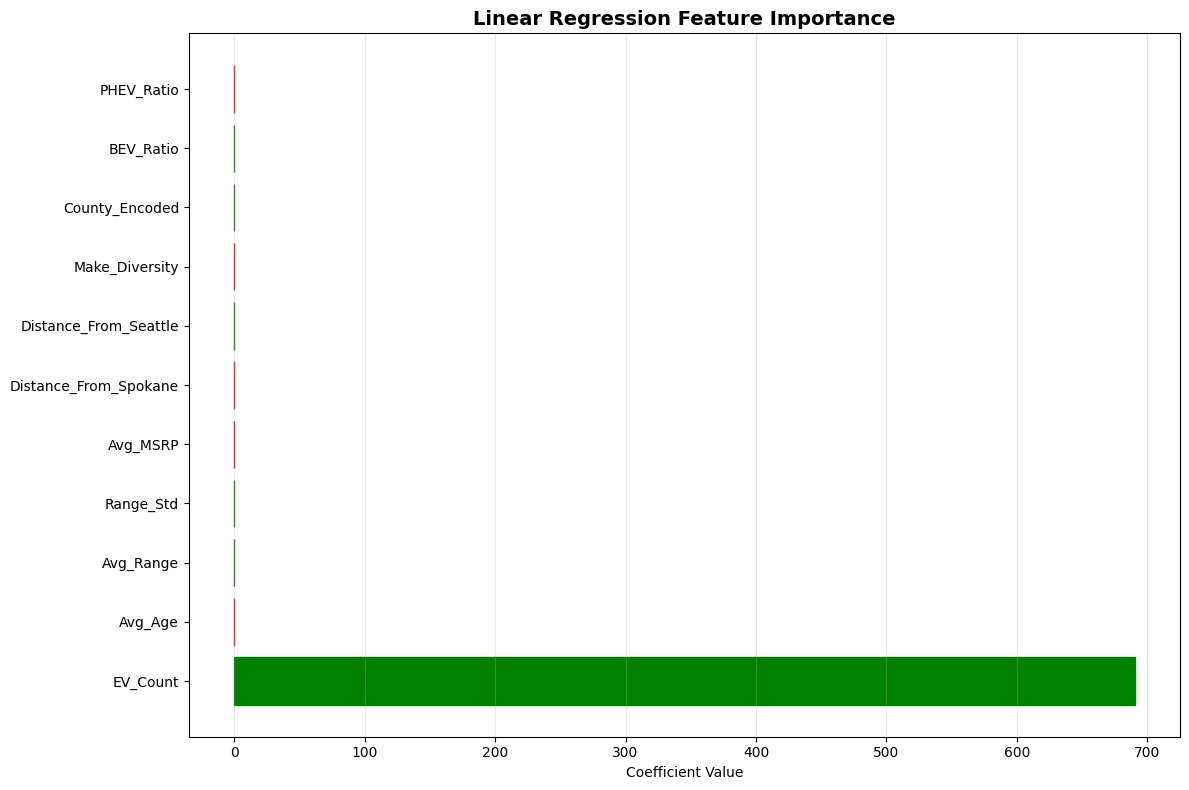

In [6]:
# Feature Importance Analysis
print("Analyzing Feature Importance...")

# Get feature coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (by coefficient magnitude):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(feature_importance)), feature_importance['Coefficient'])
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Color bars based on positive/negative coefficients
for i, bar in enumerate(bars):
    if feature_importance.iloc[i]['Coefficient'] > 0:
        bar.set_color('green')
    else:
        bar.set_color('red')

plt.tight_layout()
plt.show()


Creating Model Evaluation Visualizations...


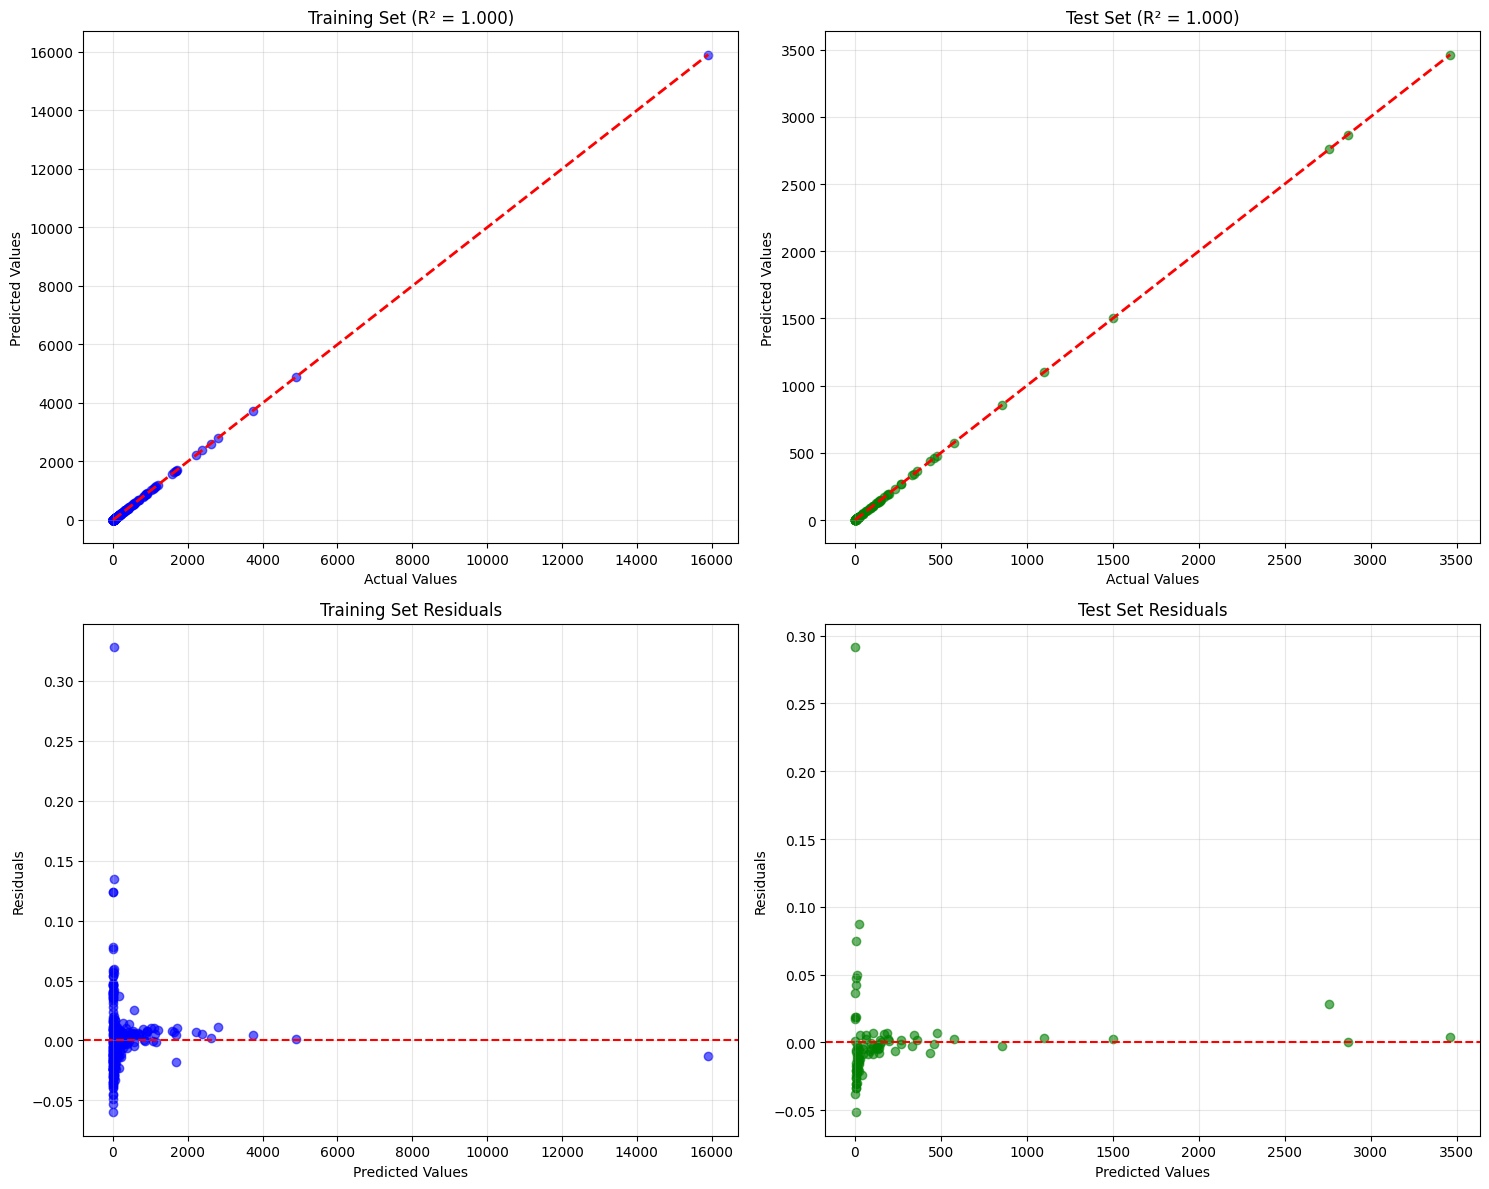

✓ Model evaluation visualizations created


In [7]:
# Model Evaluation Visualizations
print("Creating Model Evaluation Visualizations...")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted (Training)
axes[0,0].scatter(y_train, y_train_pred, alpha=0.6, color='blue')
axes[0,0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Values')
axes[0,0].set_ylabel('Predicted Values')
axes[0,0].set_title(f'Training Set (R² = {train_r2:.3f})')
axes[0,0].grid(True, alpha=0.3)

# 2. Actual vs Predicted (Test)
axes[0,1].scatter(y_test, y_test_pred, alpha=0.6, color='green')
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,1].set_xlabel('Actual Values')
axes[0,1].set_ylabel('Predicted Values')
axes[0,1].set_title(f'Test Set (R² = {test_r2:.3f})')
axes[0,1].grid(True, alpha=0.3)

# 3. Residuals (Training)
residuals_train = y_train - y_train_pred
axes[1,0].scatter(y_train_pred, residuals_train, alpha=0.6, color='blue')
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Values')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Training Set Residuals')
axes[1,0].grid(True, alpha=0.3)

# 4. Residuals (Test)
residuals_test = y_test - y_test_pred
axes[1,1].scatter(y_test_pred, residuals_test, alpha=0.6, color='green')
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Predicted Values')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Test Set Residuals')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Model evaluation visualizations created")


In [8]:
# Save Model and Results
print("Saving Model and Results...")

# Save the trained model
joblib.dump(lr_model, '../../models/linear_regression.pkl')
print("✓ Linear Regression model saved")

# Save feature importance
feature_importance.to_csv('../../data/processed/lr_feature_importance.csv', index=False)
print("✓ Feature importance saved")

# Save model performance metrics
performance_metrics = {
    'model_name': 'Linear Regression',
    'train_mse': float(train_mse),
    'test_mse': float(test_mse),
    'train_r2': float(train_r2),
    'test_r2': float(test_r2),
    'train_mae': float(train_mae),
    'test_mae': float(test_mae),
    'n_features': len(feature_columns),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test)
}

import json
with open('../../data/processed/lr_performance_metrics.json', 'w') as f:
    json.dump(performance_metrics, f, indent=2)

print("✓ Performance metrics saved")

# Display final summary
print("\nLinear Regression Model Summary:")
print("=" * 40)
print(f"Model: Linear Regression")
print(f"Features: {len(feature_columns)}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

print("\nTop 5 Most Important Features:")
print(feature_importance.head()[['Feature', 'Coefficient']].to_string(index=False))

print("\nLinear Regression model training completed successfully!")


Saving Model and Results...
✓ Linear Regression model saved
✓ Feature importance saved
✓ Performance metrics saved

Linear Regression Model Summary:
Model: Linear Regression
Features: 11
Training R²: 1.0000
Test R²: 1.0000
Test MSE: 0.0014
Test MAE: 0.0180

Top 5 Most Important Features:
  Feature  Coefficient
 EV_Count   690.454161
  Avg_Age    -0.201895
Avg_Range     0.104453
Range_Std     0.095256
 Avg_MSRP    -0.040387

Linear Regression model training completed successfully!
